In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from StatL1Z2 import generuj_pareto
import scipy.stats

12.182679103771283 12.182493960703473
0.25312081677251835 0.2550156343901585


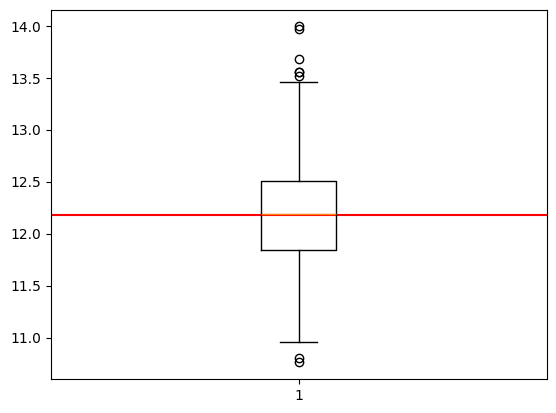

In [3]:
miu, sigma = 2, 1
n, m = 1000, 1000
tab = []

for _ in range(m):
    X = np.random.lognormal(miu, sigma, n)
    EX = np.mean(X)
    tab.append(EX)

plt.plot(np.linspace(0.5, 1.5, m), [np.exp(miu + (sigma**2)/2) for _ in range(m)], 'r')
plt.boxplot(tab)

srednia_emp = np.mean(tab)
srednia_teor = np.exp(miu + (sigma**2)/2)
wariancja_emp = np.var(tab)
wariancja_teor = np.exp(2*miu + sigma**2) * (np.exp(sigma**2) - 1) / n
print(srednia_emp, srednia_teor)
print(wariancja_emp, wariancja_teor)

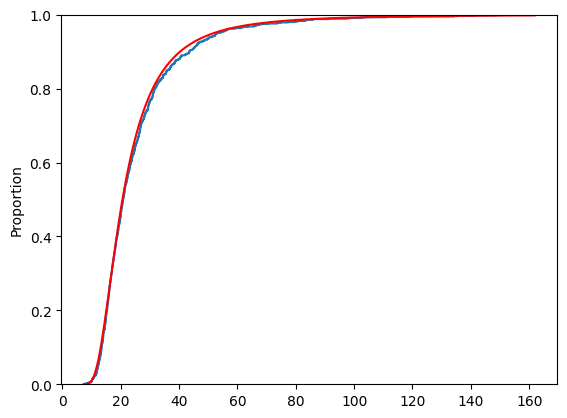

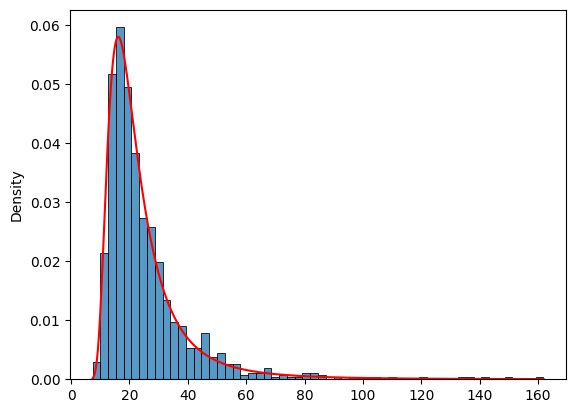

In [4]:
U_tab = []
alfa, lam = 3, 2
for _ in range(m):
    X = generuj_pareto(lam, alfa, n)
    U = max(X)
    U_tab.append(U)

x_arg = np.linspace(min(U_tab), max(U_tab), n)
F_X = 1 - (lam/(lam + x_arg))**alfa
F_U = F_X ** n 
sn.ecdfplot(U_tab)
plt.plot(x_arg, F_U, 'r')
plt.show()

f_x = (alfa*lam**alfa)/((lam+x_arg)**(alfa+1))
f_u = n * F_X ** (n-1) * f_x
sn.histplot(U_tab, stat='density')
plt.plot(x_arg, f_u, 'r')
plt.show()

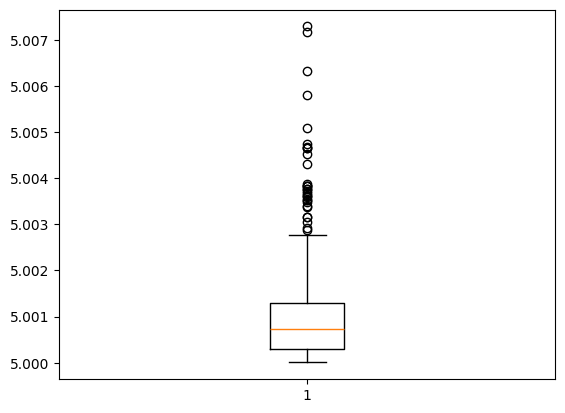

In [5]:
# zadanie 7
theta = 5
n = 1000
M = 500

def f(theta, n):
    U = np.random.uniform(0, 1, n) 
    return -np.log(U) + theta

tab = []
for _ in range(M):
    tab.append(min(f(theta, n)))
    
plt.boxplot(tab)
plt.show()

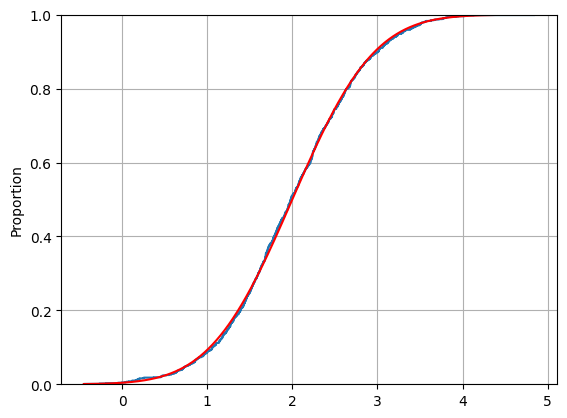

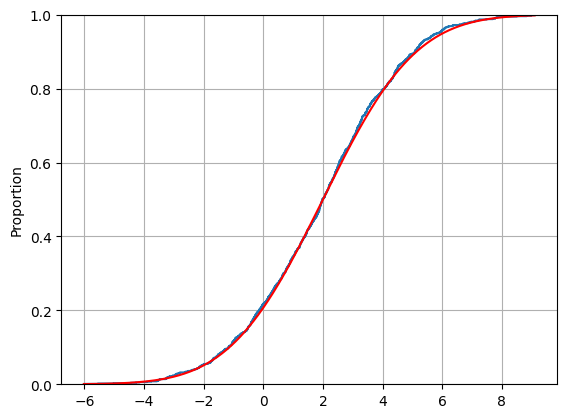

In [6]:
#10
mi, sigma = 2, 2
theta1_tab, theta2_tab = [], []
for _ in range(n):
    X = np.random.normal(mi, sigma, 7)
    theta1 = np.mean(X)
    theta2 = (2 * X[0] - X[5] + X[3]) / 2
    theta1_tab.append(theta1)
    theta2_tab.append(theta2)

sn.ecdfplot(theta1_tab)
x_arg = np.linspace(min(theta1_tab), max(theta1_tab), n)
F = scipy.stats.norm.cdf(x_arg, loc=mi, scale=np.sqrt((sigma**2)/7))
plt.plot(x_arg, F, 'r')
plt.grid(True)
plt.show()

sn.ecdfplot(theta2_tab)
y_arg = np.linspace(min(theta2_tab), max(theta2_tab), n)
G = scipy.stats.norm.cdf(y_arg, loc=mi, scale=np.sqrt(3 * (sigma**2)/2))
plt.plot(y_arg, G, 'r')
plt.grid(True)
plt.show()

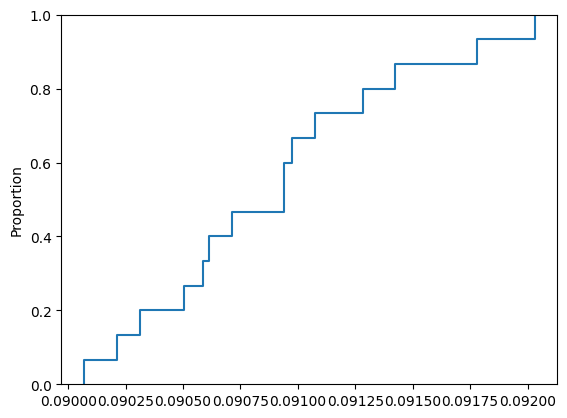

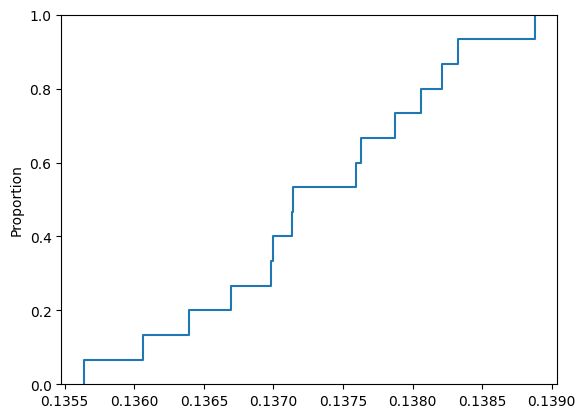

In [13]:
miu, sigma, n = 5, 1, 5
N = 2*n+1
k = 500
M = 100
means1, means2 = [], []
for _ in range(15):
    MSE1_tab, MSE2_tab = [], []
    for _ in range(M):
        theta1_tab, theta2_tab = [], []
        for _ in range(k):
            X = np.random.normal(miu, sigma, N)
            theta1, theta2 = np.mean(X), np.median(X)
            theta1_tab.append(theta1)
            theta2_tab.append(theta2)
        MSE1 = 0
        for char in theta1_tab:
            MSE1 += (char - miu)**2 
        MSE1 = MSE1 / k
        MSE2 = 0
        for char in theta2_tab:
            MSE2 += (char - miu)**2 
        MSE2 = MSE2 / k
        MSE1_tab.append(MSE1)
        MSE2_tab.append(MSE2)

    
    means1.append(np.mean(MSE1_tab))
    means2.append(np.mean(MSE2_tab))
sn.ecdfplot(means1)
plt.show()
sn.ecdfplot(means2)
plt.show()